<a href="https://colab.research.google.com/github/chenuli949/AI-movie-review-analysis/blob/Dinuri/notebooks/01_EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# Check if the IMDB Dataset.csv file exists
csv_file_path = '/content/IMDB Dataset.csv'
if os.path.exists(csv_file_path):
    print(f"The dataset '{os.path.basename(csv_file_path)}' exists at '{csv_file_path}'.")
else:
    print(f"The dataset '{os.path.basename(csv_file_path)}' does not exist at '{csv_file_path}'.")

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv")

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
print(df.columns.tolist())
print()
print(df.info())

['review', 'sentiment']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [6]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418


In [8]:
df = df.dropna(subset=['review', 'sentiment']).copy()

print("Dataset shape after removing missing values:", df.shape)

Dataset shape after removing missing values: (50000, 2)


In [9]:
df['review_length'] = df['review'].str.len()

print(df['review_length'].describe())

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


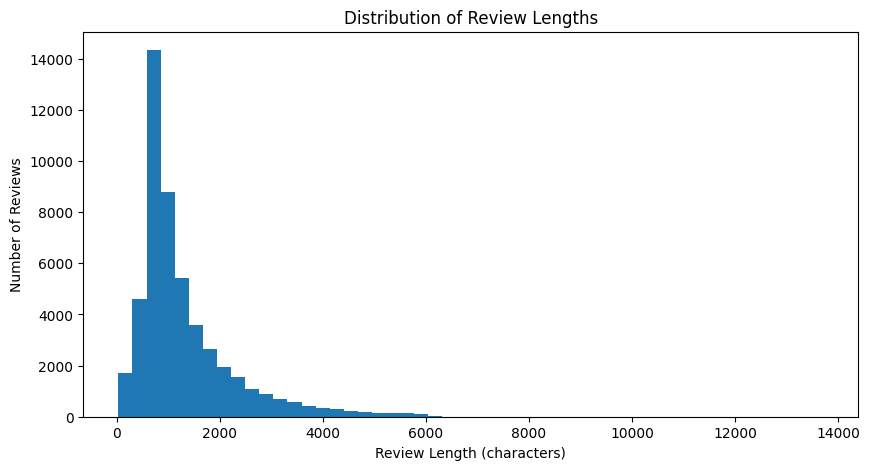

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(df['review_length'], bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")

plt.show()

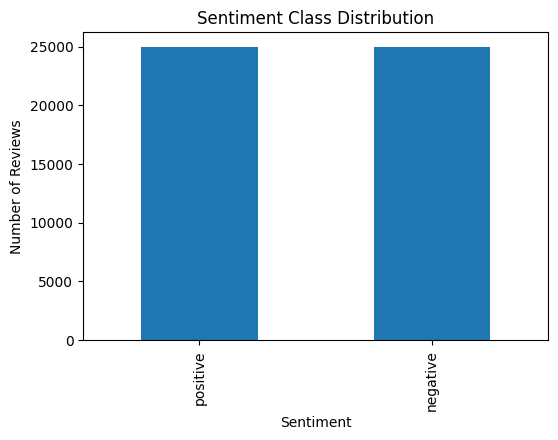

In [11]:
plt.figure(figsize=(6, 4))

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [12]:
print("Positive review:")
print(df[df["sentiment"] == "positive"]["review"].iloc[0])

print("\n" + "="*80 + "\n")

print("Negative review:")
print(df[df["sentiment"] == "negative"]["review"].iloc[0])

Positive review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [14]:
import re

def clean_text(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading and trailing whitespace
    text = text.strip()

    return text

In [15]:
df["clean_review"] = df["review"].apply(clean_text)

In [16]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,A wonderful little production. The filming tec...
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is..."


In [17]:
for i in range(3):
    print("ORIGINAL:")
    print(df["review"].iloc[i][:500])

    print("\nCLEANED:")
    print(df["clean_review"].iloc[i][:500])

    print("\n" + "="*100 + "\n")

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

CLEANED:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ 

In [18]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

In [19]:
print(df[["sentiment", "label"]].head(10))

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1
5  positive      1
6  positive      1
7  negative      0
8  negative      0
9  positive      1


In [20]:
print(df[["sentiment", "label"]].head(10))

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1
5  positive      1
6  positive      1
7  negative      0
8  negative      0
9  positive      1


In [21]:
print(df["label"].value_counts())

label
1    25000
0    25000
Name: count, dtype: int64


In [22]:
X = df["clean_review"].values
y = df["label"].values

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000,)
y shape: (50000,)


In [24]:
from sklearn.model_selection import train_test_split
import numpy as np

SEED = 42

indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=y[temp_idx]
)

print("Training:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Training: 40000
Validation: 5000
Test: 5000


In [25]:
print("Training distribution:")
print(y[train_idx])

print("\nValidation distribution:")
print(y[val_idx])

print("\nTest distribution:")
print(y[test_idx])

Training distribution:
[1 0 0 ... 0 0 0]

Validation distribution:
[0 0 0 ... 0 1 0]

Test distribution:
[0 1 1 ... 1 0 1]


In [26]:
print("Training:")
print(pd.Series(y[train_idx]).value_counts(normalize=True))

print("\nValidation:")
print(pd.Series(y[val_idx]).value_counts(normalize=True))

print("\nTest:")
print(pd.Series(y[test_idx]).value_counts(normalize=True))

Training:
1    0.5
0    0.5
Name: proportion, dtype: float64

Validation:
0    0.5
1    0.5
Name: proportion, dtype: float64

Test:
0    0.5
1    0.5
Name: proportion, dtype: float64


In [28]:
X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

In [29]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (40000,)
y_train: (40000,)
X_val: (5000,)
y_val: (5000,)
X_test: (5000,)
y_test: (5000,)


In [30]:
np.save("train_indices.npy", train_idx)
np.save("validation_indices.npy", val_idx)
np.save("test_indices.npy", test_idx)

In [31]:
processed_df = df[["clean_review", "label"]].copy()

processed_df.to_csv(
    "processed_imdb_reviews.csv",
    index=False
)

In [32]:
import numpy as np

np.save("train_indices.npy", train_idx)
np.save("validation_indices.npy", val_idx)
np.save("test_indices.npy", test_idx)

print("Preprocessing files saved.")

Preprocessing files saved.
